Prepare the Data

In [25]:
import pandas as pd
import numpy as np

df=pd.read_csv("data/Nepal_RoadAccidents_Cleaned.csv")
X = df[['Latitude','Longitude']]

Import the Model

In [26]:
from sklearn.cluster import KMeans

Train the Model

Example with 5 clusters:

In [27]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['cluster_kmeans'] = kmeans.fit_predict(X)

Get Cluster Centers

In [28]:
centers = kmeans.cluster_centers_

Plot Clusters

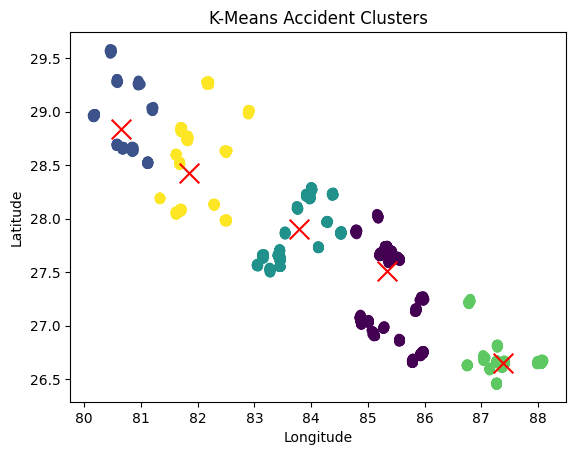

In [29]:
import matplotlib.pyplot as plt

plt.scatter(df['Longitude'], df['Latitude'], 
            c=df['cluster_kmeans'], cmap='viridis')

plt.scatter(centers[:,1], centers[:,0], 
            color='red', marker='x', s=200)

plt.title("K-Means Accident Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Choosing the Best Number of Clusters

Use the Elbow Method.

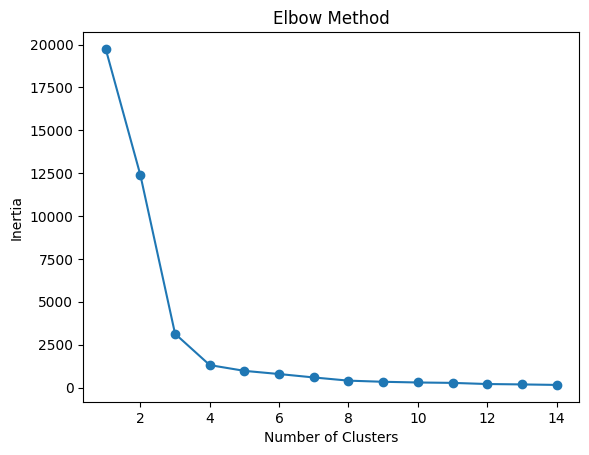

In [30]:
inertia = []

for k in range(1,15):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,15), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

#Where the graph bends = best K.